In [8]:
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [9]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.35),

    Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

Model: "sequential_2"


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤

 Total params: 421,642 (1.61 MB)


 Trainable params: 421,642 (1.61 MB)


 Non-trainable params: 0 (0.00 B)


In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7683 - loss: 0.6285 - val_accuracy: 0.8562 - val_loss: 0.3950 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8559 - loss: 0.3988 - val_accuracy: 0.8823 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8722 - loss: 0.3520 - val_accuracy: 0.8897 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8839 - loss: 0.3216 - val_accuracy: 0.8996 - val_loss: 0.2738 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8895 - loss: 0.3016 - val_accuracy: 0.9014 - val_loss: 0.2628 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8962 - loss: 0.2843 - val_accuracy: 0.9057 - val_loss: 0.2561 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8999 - loss: 0.2700 - 

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Точність на тестових даних: {test_accuracy:.4f}")
print(f"Втрати на тестових даних: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9234 - loss: 0.2250
Точність на тестових даних: 0.9234
Втрати на тестових даних: 0.2250


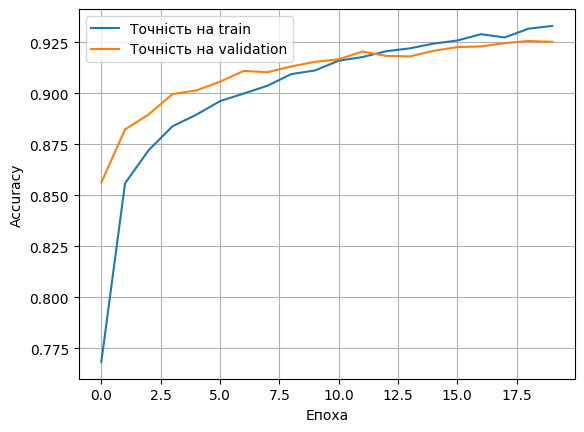

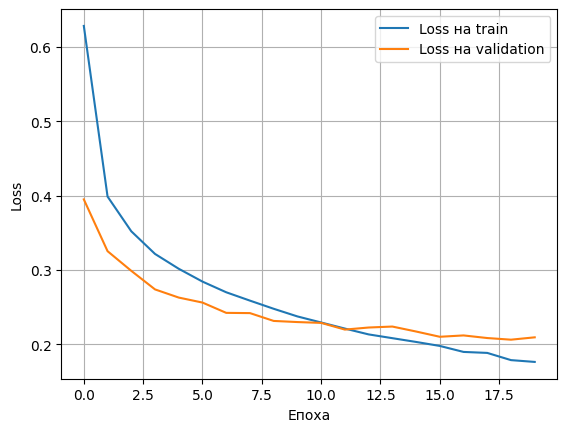

In [13]:
plt.plot(history.history["accuracy"], label="Точність на train")
plt.plot(history.history["val_accuracy"], label="Точність на validation")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["loss"], label="Loss на train")
plt.plot(history.history["val_loss"], label="Loss на validation")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


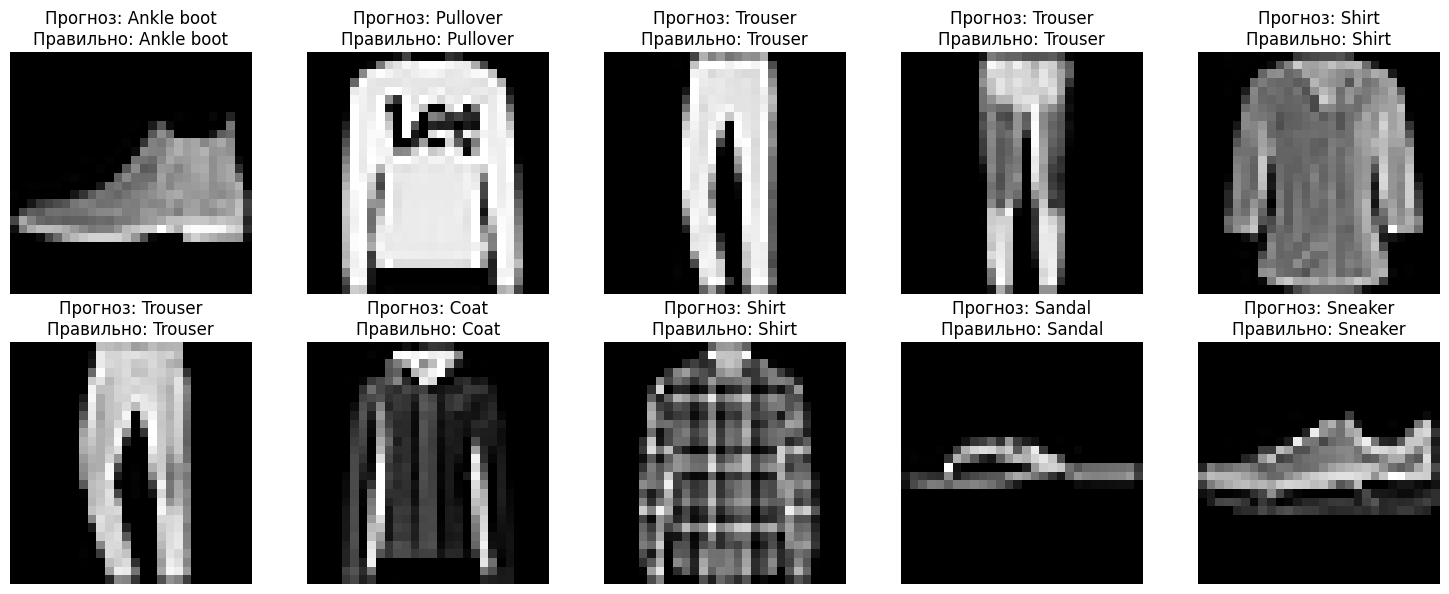

In [14]:
predictions = model.predict(X_test)

plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    predicted_class = np.argmax(predictions[i])
    true_class = y_test[i]

    plt.title(
        f"Прогноз: {class_names[predicted_class]}\nПравильно: {class_names[true_class]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
'''
Було створено згорткову нейронну мережу для класифікації зображень одягу з датасету Fashion-MNIST.

Мережа складається з кількох згорткових шарів Conv2D, шарів MaxPooling2D для зменшення розмірності та Dropout для зменшення перенавчання.

Після навчання модель показала високу точність на тестових даних. Згорткова нейронна мережа працює краще за звичайну dense-мережу,
оскільки вона враховує просторову структуру зображень.
'''

In [1]:
import tensorflow as tf
from keras.datasets import fashion_mnist
from keras.applications import VGG16
from keras import models
from keras import layers
from keras.optimizers import Adam
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

def preprocess_images(images):
    images = images[..., tf.newaxis]
    images = tf.image.resize(images, (96, 96))
    images = tf.image.grayscale_to_rgb(images)
    return images

X_train_vgg = preprocess_images(X_train)
X_test_vgg = preprocess_images(X_test)

vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

vgg_base.trainable = False

In [2]:
model = models.Sequential([
   vgg_base,
   layers.Flatten(),
   layers.Dense(512, activation="relu"),
   layers.Dropout(0.5),
   layers.Dense(256, activation="relu"),
   layers.Dropout(0.4),
   layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤

 Total params: 17,208,394 (65.64 MB)


 Trainable params: 2,493,706 (9.51 MB)


 Non-trainable params: 14,714,688 (56.13 MB)


In [3]:
history = model.fit(
    X_train_vgg,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 96s 213ms/step - accuracy: 0.3681 - loss: 1.8492 - val_accuracy: 0.7707 - val_loss: 0.9595
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 180ms/step - accuracy: 0.6715 - loss: 0.9961 - val_accuracy: 0.8060 - val_loss: 0.6187
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 74s 197ms/step - accuracy: 0.7484 - loss: 0.7496 - val_accuracy: 0.8260 - val_loss: 0.5115
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 68s 180ms/step - accuracy: 0.7809 - loss: 0.6387 - val_accuracy: 0.8362 - val_loss: 0.4616
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 178ms/step - accuracy: 0.8001 - loss: 0.5790 - val_accuracy: 0.8442 - val_loss: 0.4313
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 178ms/step - accuracy: 0.8165 - loss: 0.5340 - val_accuracy: 0.8503 - val_loss: 0.4088
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 178ms/step - accuracy: 0.8268 - loss: 0.5010 - val_accuracy: 0.8567 - val_loss: 0.3919
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 67s 179ms/step - accuracy: 0.8340 - loss: 0

In [4]:
vgg_base.trainable = True

for layer in vgg_base.layers:
    layer.trainable = False

for layer in vgg_base.layers:
    if "block5" in layer.name:
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [5]:
history = model.fit(
    X_train_vgg,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 122s 500ms/step - accuracy: 0.8878 - loss: 0.3165 - val_accuracy: 0.9022 - val_loss: 0.2663
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 69s 365ms/step - accuracy: 0.9037 - loss: 0.2756 - val_accuracy: 0.9103 - val_loss: 0.2472
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 69s 365ms/step - accuracy: 0.9126 - loss: 0.2493 - val_accuracy: 0.9127 - val_loss: 0.2341
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 69s 365ms/step - accuracy: 0.9207 - loss: 0.2303 - val_accuracy: 0.9177 - val_loss: 0.2275
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 69s 365ms/step - accuracy: 0.9252 - loss: 0.2126 - val_accuracy: 0.9202 - val_loss: 0.2199
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 69s 365ms/step - accuracy: 0.9285 - loss: 0.2026 - val_accuracy: 0.9242 - val_loss: 0.2129
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 69s 366ms/step - accuracy: 0.9343 - loss: 0.1871 - val_accuracy: 0.9232 - val_loss: 0.2116
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 83s 369ms/step - accuracy: 0.9391 - loss: 

In [6]:
test_loss, test_accuracy = model.evaluate(X_test_vgg, y_test)

print(f"Точність на тестових даних: {test_accuracy:.4f}")
print(f"Втрати на тестових даних: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.9192 - loss: 0.2208
Точність на тестових даних: 0.9192
Втрати на тестових даних: 0.2208


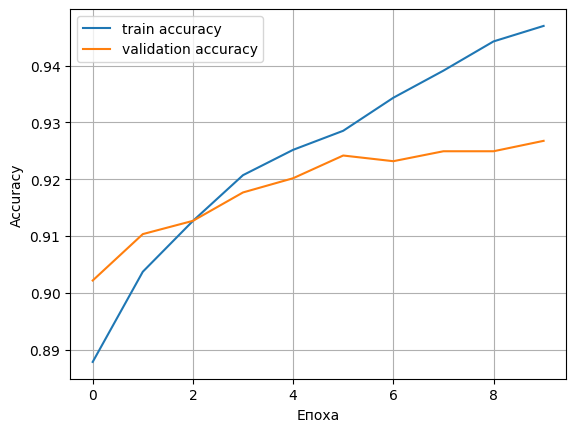

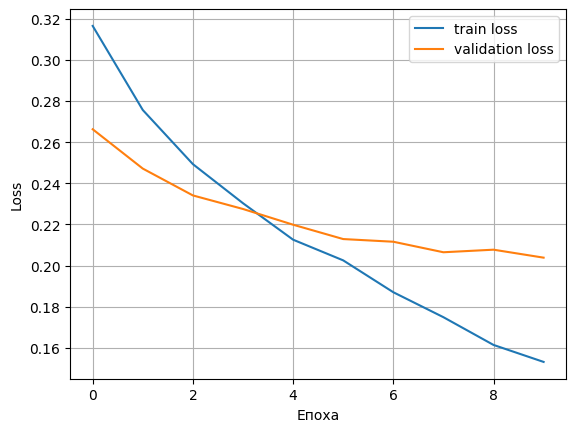

In [7]:
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="validation accuracy")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
'''
Було створено згорткову нейронну мережу, яка використовує VGG16 як згорткову основу.

Оскільки VGG16 працює з RGB-зображеннями, зображення Fashion-MNIST були змінені з формату 28×28×1
на 48x48x3.

Згорткова основа VGG16 була заморожена, тобто її ваги не навчалися. До неї було додано власний
класифікатор із Dense-шаром, Dropout та вихідним шаром на 10 класів.

Модель була навчена на датасеті Fashion-MNIST і протестована на тестовій вибірці.
'''